### testing ground

In [233]:
## import numpy as np
import pandas as pd
import networkx as nx
import numpy as np
import functions_regular as fnr
import functions_subtrees as fns
import functions_regular_wc as fnr_wc
import functions_subtrees_wc as fns_wc
import matplotlib.pyplot as plt
import importlib
import numpy.lib.recfunctions as rfn
import cProfile as cp
import random as rnd
import itertools as it
import collections
import math
import permanent as per
import permanent_fast as per_f
import time
import pickle
importlib.reload(fnr)
importlib.reload(fns)
importlib.reload(fnr_wc)
importlib.reload(fns_wc)
importlib.reload(per)
importlib.reload(per_f)

<module 'permanent_fast' from '/Users/mbpr/Desktop/internships/CU Boulder Summer 2019/Motif discovery/motif-discovery/src/permanent_fast.py'>

## console

In [234]:
f = open('test_data/CommunityFitNet_updated.pickle', 'rb')
data = pickle.load(f)
data_edgelists = data['edges_id']

networkIndex = 4

networkGraph = nx.Graph()
edges = data_edgelists.iloc[networkIndex]
networkGraph.add_edges_from(edges)
networkString = graphToString(networkGraph)

queryString = '[[0,1], [0,2], [1,3], [2,3]]'  #index 1
queryGraph = parseStringToGraph(queryString)

# queryGraphCopy = parseStringToGraph(queryString)

# Special = nx.read_pajek("test_data/special_withlabels.net")
# stringSpecial = graphToString(Special)
# specialGraph = parseStringToGraph(stringSpecial)

print('fnr:', fnr_wc.findSubgraphInstances(queryGraph, networkGraph))
print('fns:', fns_wc.findSubgraphInstances(queryString, networkString))

# aut = fnr_wc.findSubgraphInstances(queryGraph, queryGraphCopy, False)  # returns list of automorphisms of H
# eqClasses = fnr_wc.findEquivalenceClasses(aut)
# HE = list(eqClasses.keys())
# M = fnr_wc.symmetryConditions(aut)
# print([tuple(f.getMap()) for f in aut])
# print(HE, M)

fnr: 282
fns: 282


In [208]:
def mostConstrainedNode(D, H):
    # print('##### MOST CONSTRAINED NODE #####')
    # print('domain of partial map: ', end='')
    # print(D)

    neighborsD = {None}

    # list of neighbors of D
    for d in D:
        neighborsD = neighborsD.union(set(H[d]))

    neighborsD = neighborsD.difference({None})

    # neighbors of D exclusively in H with the number of neighbors in D
    neighborsD = neighborsD.difference(set(D))
    # print('neighbors of D: ', end='')
    # print(neighborsD)

    neighborsD = [(node, H.nodes[node]['coreness']) for node in neighborsD]
    m = max(neighborsD, key = itemgetter(1))[0]

    return m

-4

## try ryser's formula

In [239]:
mat = np.random.randint(10, size = (10,10))

In [240]:
start_time_r = time.time()
out_r = per.permanent(mat)
delta_r = time.time() - start_time_r  

print(out_r)
print(delta_r)

11484418190575
14.257670879364014


In [241]:
start_time_f = time.time()
out_f = per_f.permanent_fast(mat)
delta_f = time.time() - start_time_f 

print(out_f)
print(delta_f)

11484418190575
0.014972209930419922


### test correctness on special graph

In [226]:
Special = nx.read_pajek("test_data/special_withlabels.net")
stringSpecial = graphToString(Special)

graphSize = 6

inputFile = 'test_data/allgraphs' + str(graphSize) + '.txt'
f = open(inputFile, 'r')
data = f.readlines()
out_fns_wc = [None]*len(data)
out_fnr_wc = [None]*len(data)

for index, line in enumerate(data):
    stringQuery = line.rstrip()
    Query = parseStringToGraph(stringQuery)
    Special = parseStringToGraph(stringSpecial)
    
    out_fns_wc[index] = stringQuery + ' ' + str(fns_wc.findSubgraphInstances(stringQuery, stringSpecial)) + '\n'
    out_fnr_wc[index] = stringQuery + ' ' + str(fnr_wc.findSubgraphInstances(Query, Special, True)) + '\n'
    
    print('progress:', int(index*100/len(data)))
      
outputFileRegular_wc = 'test_data/allgraphs' + str(graphSize) + 'counts_special_regular_wc_v2.txt'
outputFileSubtrees_wc = 'test_data/allgraphs' + str(graphSize) + 'counts_special_subtrees_wc_v2.txt'

progress: 0
progress: 0
progress: 1
progress: 2
progress: 3
progress: 4
progress: 5
progress: 6
progress: 7
progress: 8
progress: 8
progress: 9
progress: 10
progress: 11
progress: 12
progress: 13
progress: 14
progress: 15
progress: 16
progress: 16
progress: 17
progress: 18
progress: 19
progress: 20
progress: 21
progress: 22
progress: 23
progress: 24
progress: 25
progress: 25
progress: 26
progress: 27
progress: 28
progress: 29
progress: 30
progress: 31
progress: 32
progress: 33
progress: 33
progress: 34
progress: 35
progress: 36
progress: 37
progress: 38
progress: 39
progress: 40
progress: 41
progress: 41
progress: 42
progress: 43
progress: 44
progress: 45
progress: 46
progress: 47
progress: 48
progress: 49
progress: 50
progress: 50
progress: 51
progress: 52
progress: 53
progress: 54
progress: 55
progress: 56
progress: 57
progress: 58
progress: 58
progress: 59
progress: 60
progress: 61
progress: 62
progress: 63
progress: 64
progress: 65
progress: 66
progress: 66
progress: 67
progress: 6

In [228]:
fr_wc = open(outputFileRegular_wc, 'w')
fs_wc = open(outputFileSubtrees_wc, 'w')

fr_wc.writelines(out_fnr_wc)
fs_wc.writelines(out_fns_wc)

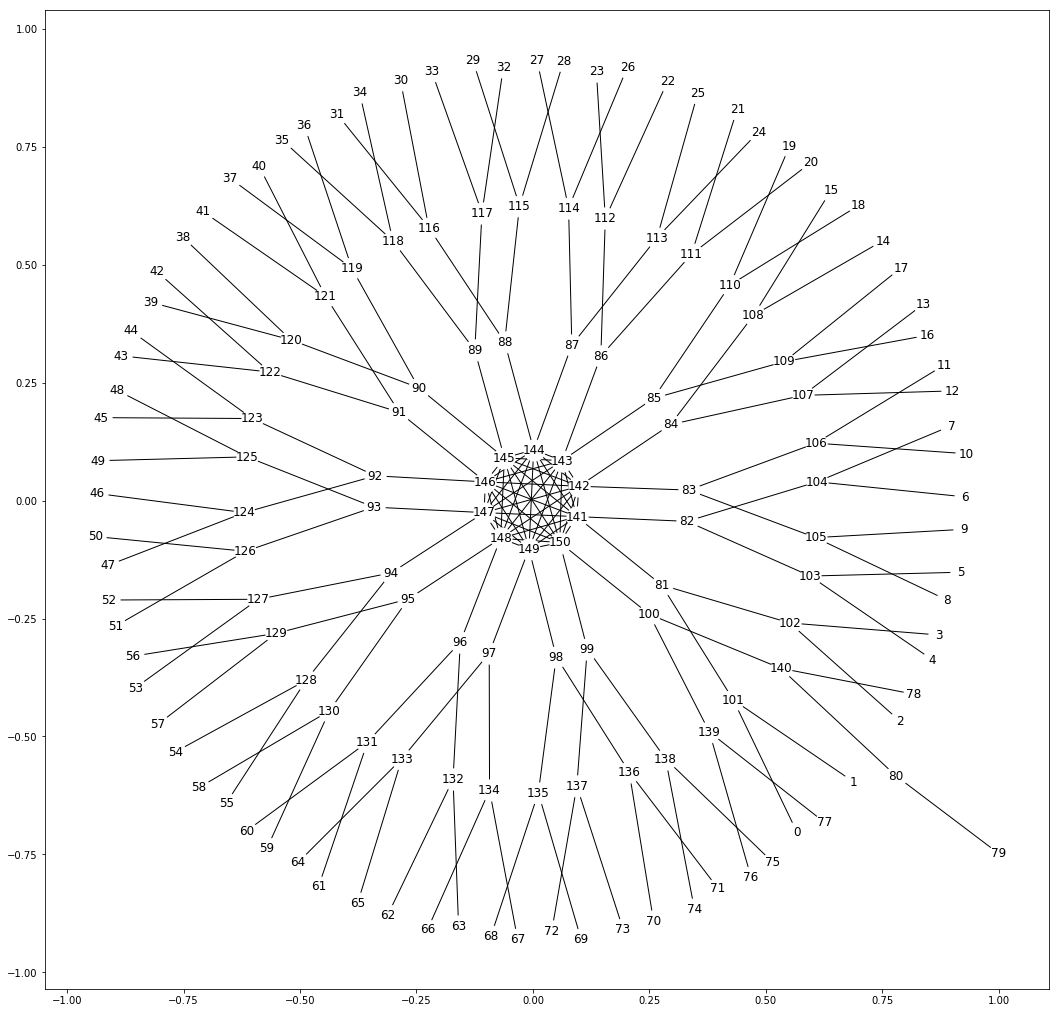

In [203]:
specialGraph = parseStringToGraph(stringSpecial)
pos = nx.drawing.kamada_kawai_layout(specialGraph, scale=1)

fnr_wc.onionDecompose(specialGraph)
mapping = {}

for i in list(specialGraph.nodes()):
    mapping[str(i)] = str(specialGraph.nodes[i]['onion_layer'])

specialGraph = nx.relabel_nodes(specialGraph, mapping)

fig, ax = plt.subplots()
fig.set_size_inches(18, 18)

nodes = nx.draw_networkx_nodes(specialGraph, pos=pos, node_size = 450, ax = ax, node_color='white')
edges = nx.draw_networkx_edges(specialGraph, pos=pos, ax = ax)
labels = nx.draw_networkx_labels(specialGraph, pos=pos, ax = ax)

plt.show()

In [4]:
# input: edges of a graph written in bracketed pairs
# output: graph with corresponding edges
def parseStringToGraph(s):
    l = []
    
    if(s[len(s)-1] == ' '):
        s = s[:-1]
    
    if(s[0] == '[' and s[len(s)-1] == ']'):
        s = s[-(len(s)-1):-1]
        start = [key for key, val in enumerate(s) if val == '[']
        end = [key for key, val in enumerate(s) if val == ']']
        comma = [key for key, val in enumerate(s) if (val == ',' and not s[key-1] == ']')]
        
        for i in range(len(start)):
            left = [v for k, v in enumerate(s) if k in range(start[i]+1, comma[i])]
            right = [v for k, v in enumerate(s) if k in range(comma[i]+1, end[i])]
            
            left = int(''.join(left))
            right = int(''.join(right))
            l.append((left, right))
    
    H = nx.Graph()
    H.add_edges_from(l)
    
    return H


# reads the text file output by Josh and returns test name, hstring,
# gstring and answer in a dict
def parseFileToDict(file):
    f = open(file, 'r')
    D = {}
    index = 0
    first = True
    
    for line in f:
        if (line[0:4] == 'Test'):
            title = line[:-1]
            
        if (line[0] == '['):
            if (first):
                hstring = line[:-1]
                first = False
            else:
                gstring = line[:-1]
                first = True
            
            
        if (ord(line[0]) >= 48 and ord(line[0]) <= 57):
            ans = int(line)
            D[index] = {'title': title,
                        'hstring': hstring,
                        'gstring': gstring,
                        'answer': ans}
            index = index + 1
    
    return D


def test_findSubgraphInstances(file, which='regular'):
    
    D = parseFileToDict(file)
    
    for key in D.keys():
        print(D[key]['title'])
        H = nx.Graph()
        G = nx.Graph()
        
        hGraph = parseStringToGraph(D[key]['hstring'])
        gGraph = parseStringToGraph(D[key]['gstring'])
        
        H.add_edges_from(hGraph.edges())
        G.add_edges_from(gGraph.edges())
        
        fns.onionDecompose(H)
        fns.onionDecompose(G)
        
        if (which == 'regular'):
            count = fnr.findSubgraphInstances(H, G, True)
            
        if (which == 'subtrees'):
            count = fns.findSubgraphInstances(H, G, True)
            
        if (which == 'hencealoft'):
            count = hencealoft_flipped(H, G)
        
        l = count
        ans = D[key]['answer']
        
        print('H: ',end='')
        print(D[key]['hstring'])
        print('G: ',end='')
        print(D[key]['gstring'])
#         print('instances: ',end='')
#         print([tuple(i.getMap()) for i in instances])
        print('correct number of instances: ',end='')
        print(ans)
        print('instances found: ',end='')
        print(l)
        
        if(l == ans):
            print('succeeded')
        else:
            print('failed')
            
        print()
        
# convert graphs to strings
def graphToString(G):
    edges = list(G.edges())
    string = '['
    
    for edge in edges:
        to_add = '[' + str(edge[0]) + ',' + str(edge[1]) + '], '
        string += to_add
        
    string = string[:len(string)-2]
    string += ']'
    
    return string

# write a function that adds a label to every node in
# the .net files
# file: file's path name
def add_label(file):
    f = open(file, 'r')
    
    data = f.readlines()
    
    for index, line in enumerate(data):
        
        split = line.split()
        print(index, data[index], split)
        
        if (len(split) == 1):
            temp = data[index].rstrip() + ' ' + data[index]
            data[index] = temp
            
    f = open(file, 'w')
    f.writelines(data)